In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../Datasets/placement.csv")

In [4]:
df.shape

(1000, 3)

In [5]:
df.sample(5)

,cgpa,placement_exam_marks,placed
334,6.56,19.0,1
406,7.14,17.0,1
847,7.20,54.0,1
34,8.15,9.0,0
258,6.12,6.0,1


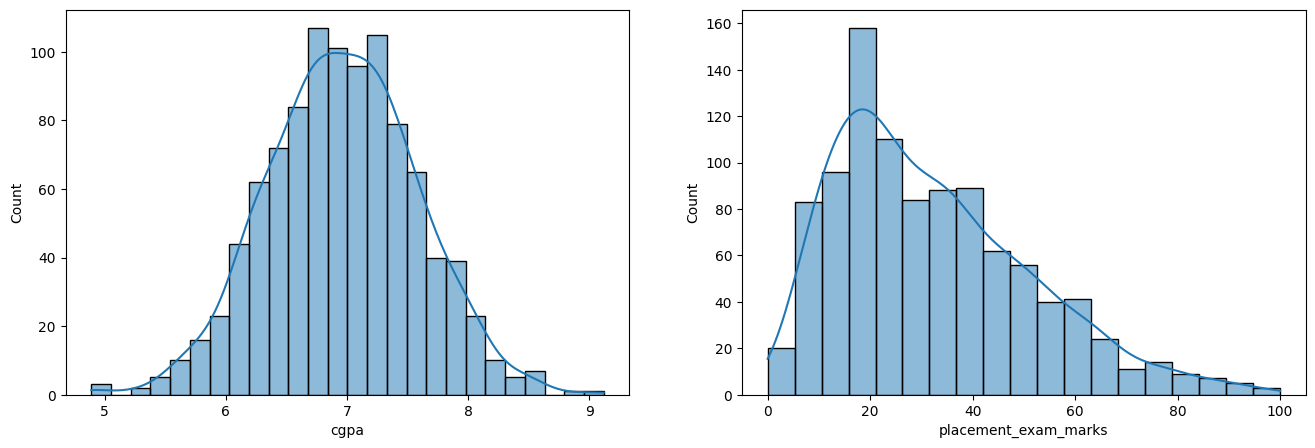

In [8]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.histplot(df["cgpa"], kde=True)

plt.subplot(122)
sns.histplot(df["placement_exam_marks"], kde=True)

plt.show()

In [9]:
df['placement_exam_marks'].skew()

0.8356419499466834

In [12]:
# df["cgpa"].describe()
print("Mean value of cgpa", df["cgpa"].mean())
print("Std value of cgpa", df["cgpa"].std()) # Standard Deviation
print("Min value of cgpa", df["cgpa"].min())
print("Max value of cgpa", df["cgpa"].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323896
Min value of cgpa 4.89
Max value of cgpa 9.12


In [14]:
# Finding the boundary values
print("Highest allowed", df["cgpa"].mean() + 3 * df["cgpa"].std())
print("Lowest allowed", df["cgpa"].mean() - 3 * df["cgpa"].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [15]:
# Finding the outliers
df[(df["cgpa"] > 8.808933625397168) | (df["cgpa"] < 5.113546374602832)]

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


## Trimming

In [20]:
new_df = df[(df["cgpa"] < 8.808933625397168) & (df["cgpa"] > 5.113546374602832)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [22]:
# Approach 2 - Calculating the Z-Score
# Z=(X−μ)/σ
df["cgpa_zscore"] = ( ( df["cgpa"] - df["cgpa"].mean() )/df["cgpa"].std() )
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [23]:
df[df["cgpa_zscore"] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [24]:
df[df["cgpa_zscore"] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [25]:
df[(df["cgpa_zscore"] > 3) | (df["cgpa_zscore"] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [27]:
# Trimming
new_df = df[(df["cgpa_zscore"] < 3) & (df["cgpa_zscore"] > -3)]
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


## Capping

In [28]:
upper_limit = df["cgpa"].mean() + 3 * df["cgpa"].std()
lower_limit = df["cgpa"].mean() - 3 * df["cgpa"].std()

In [30]:
df["cgpa"] = np.where(df["cgpa"] > upper_limit,
                     upper_limit,
                     np.where(df["cgpa"] < lower_limit,
                             lower_limit,
                             df["cgpa"]
                             )
                     )
df.shape

(1000, 4)

In [31]:
df["cgpa"].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

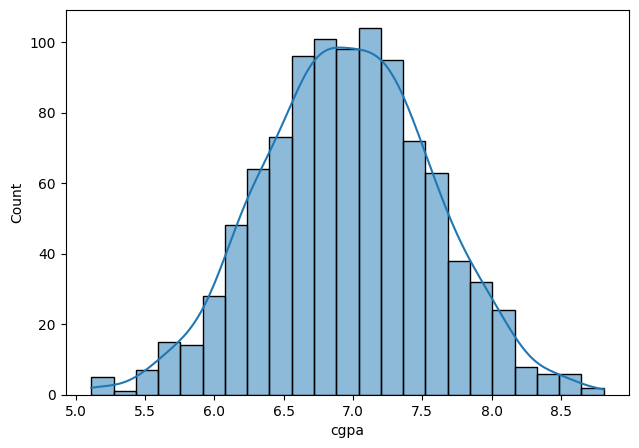

In [33]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.histplot(df["cgpa"], kde=True)
plt.show()